## Useful Documentation Links
- pandas: https://pandas.pydata.org/docs/reference/index.html
- scikitlearn: https://scikit-learn.org/stable/api/index.html
- feature engine: https://feature-engine.trainindata.com/en/latest/api_doc/index.html
- kenard stone: https://pypi.org/project/kennard-stone/
- imblearn: https://imbalanced-learn.org/stable/
- string processing: https://docs.python.org/3/library/stdtypes.html#text-sequence-type-str
- regular expressions: https://docs.python.org/3/library/re.html#module-re

In [1]:
!pip install feature_engine
!pip install scikit-learn==1.4

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import missingno as msno

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder,StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from feature_engine.imputation import MeanMedianImputer

import warnings
warnings.filterwarnings('ignore')

import adsa_utils as ad

## AGGREGATION
### 1. Aggregate at row level
- we will use charity dataset
- rows are grouped ==> fewer rows
- we cannot compare models generated on the original and aggregated data, respectively, because they are predicting different things:
  - on the original data, what's predicted is the behaviour of individual people
  - on the aggregated dataset, what we are predicting is the mode behaviour within each group.

In [3]:
# load charity data
charity = pd.read_csv('data/charity.csv', encoding='unicode_escape')
charity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2398 entries, 0 to 2397
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Pre-campaign expenditure      2398 non-null   float64
 1   Pre-campaign visits           2398 non-null   float64
 2   Pre-campaign spend category   2398 non-null   object 
 3   Pre-campaign visits category  2398 non-null   object 
 4   Total number of visits        2398 non-null   float64
 5   Total spend                   2398 non-null   float64
 6   Post Code                     2398 non-null   object 
 7   52 Mosaic Groups              2398 non-null   float64
 8   Mosaic Bands                  2398 non-null   float64
 9   Title                         2398 non-null   object 
 10  Gender                        2398 non-null   object 
 11  Year Of Birth                 2398 non-null   float64
 12  Age                           2398 non-null   float64
 13  Age

In [4]:
charity.head(3)

,Pre-campaign expenditure,Pre-campaign visits,Pre-campaign spend category,Pre-campaign visits category,Total number of visits,Total spend,Post Code,52 Mosaic Groups,Mosaic Bands,Title,Gender,Year Of Birth,Age,Age category,Response to campaign
0,56.0,2.0,£50-£100,2 Visits,2.0,56.0,SE27 0QE,40.0,9.0,MISS,Female,1975.0,19.0,18-25 years,Non-responder
1,60.0,1.0,£50-£100,1 Visit,1.0,60.0,DN16 3TA,11.0,3.0,MISS,Female,1974.0,20.0,18-25 years,Non-responder
2,70.0,5.0,£50-£100,5 Or More Visits,5.0,70.0,WV12 5LB,13.0,4.0,MR,Male,1974.0,20.0,18-25 years,Non-responder


In [5]:
print(charity.columns)

Index(['Pre-campaign expenditure', 'Pre-campaign visits',
       'Pre-campaign spend category', 'Pre-campaign visits category',
       'Total number of visits', 'Total spend', 'Post Code',
       '52 Mosaic Groups', 'Mosaic Bands', 'Title', 'Gender', 'Year Of Birth',
       'Age', 'Age category', 'Response to campaign'],
      dtype='object')


In [6]:
charity['Total spend'].value_counts()

Total spend
60.0     69
80.0     55
52.0     51
74.0     50
51.0     50
         ..
359.0     1
224.0     1
147.0     1
379.0     1
243.0     1
Name: count, Length: 317, dtype: int64

In [7]:
# 1.1. aggregate using average and std of a numerical attribute
agg_avg_data = charity.groupby('Total spend')[['Pre-campaign expenditure', 'Pre-campaign visits',
       'Total number of visits', '52 Mosaic Groups', 'Mosaic Bands'
]].mean().reset_index().fillna(0)
agg_avg_data.head(3)

,Total spend,Pre-campaign expenditure,Pre-campaign visits,Total number of visits,52 Mosaic Groups,Mosaic Bands
0,0.0,3.208333,0.5,0.708333,16.041667,3.958333
1,2.0,0.000000,0.0,2.000000,7.000000,2.000000
2,3.0,3.000000,3.0,3.000000,43.000000,10.000000


In [8]:
# 1.2. aggregate age using std by total spend and rename the age column
agg_std_age = charity.groupby('Total spend')['Age'].std().reset_index().fillna(0)
# optionally we can rename the column
agg_std_age.rename(columns={'Age': 'Age_std'}, inplace=True)
print(agg_std_age.shape)
agg_std_age.head(3)

(317, 2)


,Total spend,Age_std
0,0.0,13.236355
1,2.0,0.000000
2,3.0,0.000000


In [9]:
# 1.3. aggregate label column using mode by total spend and rename
aggr_labels = charity.groupby('Total spend')['Response to campaign'
                  ].agg(pd.Series.mode).reset_index().fillna('?')
print(aggr_labels.shape)
aggr_labels.head(3)

(317, 2)


,Total spend,Response to campaign
0,0.0,Non-responder
1,2.0,Responder
2,3.0,Non-responder


In [10]:
# merge the 2 previous regular attributes dataframes on Total spend
aggr_data = pd.merge(agg_avg_data, agg_std_age, on='Total spend')
aggr_data = pd.merge(aggr_data, aggr_labels, on='Total spend')
aggr_data.head(3)

,Total spend,Pre-campaign expenditure,Pre-campaign visits,Total number of visits,52 Mosaic Groups,Mosaic Bands,Age_std,Response to campaign
0,0.0,3.208333,0.5,0.708333,16.041667,3.958333,13.236355,Non-responder
1,2.0,0.000000,0.0,2.000000,7.000000,2.000000,0.000000,Responder
2,3.0,3.000000,3.0,3.000000,43.000000,10.000000,0.000000,Non-responder


In [11]:
aggr_data['Response to campaign'].value_counts()

Response to campaign
Responder                     210
Non-responder                  90
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
[Non-responder, Responder]      1
Name: count, dtype: int64

In [12]:
# as seen in previous cell, some values are lists instead of string label and this
# happens because the mode function returns a list if there are more than 1 mode values
# so we need to retain only one value from those lists; first we need to convert to string
aggr_data['Response to campaign'] = aggr_data['Response to campaign'].astype('str')
# then we need to replace the string '[Non-responder, Responder]' with 'Non-responder'
aggr_data['Response to campaign'][aggr_data['Response to campaign'] == "['Non-responder' 'Responder']"] = 'Non-responder'
aggr_data['Response to campaign'].value_counts()

Response to campaign
Responder        210
Non-responder    107
Name: count, dtype: int64

### 2. Aggregate at attribute level
- we will use the golf dataset
- the number of rows remains the same
- we first generate the baseline model with the original features
- then we build and evaluate the model with the new features

In [13]:
golf = pd.read_csv('data/golf.csv', sep=';')
golf.head(3)

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85,85,False,no
1,sunny,80,90,True,no
2,overcast,83,78,False,yes


In [14]:
golf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     int64 
 2   Humidity     14 non-null     int64 
 3   Wind         14 non-null     bool  
 4   Play         14 non-null     object
dtypes: bool(1), int64(2), object(2)
memory usage: 594.0+ bytes


In [15]:
# separate the reg.attr. from the label attr.
golf_X = golf[golf.columns.difference(['Play'])]
golf_y = golf['Play']
# convert obj. cols to category cols
enc = LabelEncoder()
golf_X['Outlook'] = enc.fit_transform(golf_X['Outlook'])
# we will use a DT to model a baseline
dt_clf = DecisionTreeClassifier(random_state=43)
# only do crossval since we have a very small dataset
ad.cross_validation_avg_scores(golf_X, golf_y, dt_clf)

Mean Accuracy is 43.33 +/- 13.33
Mean Precision is 31.67 +/- 21.98
Mean Recall is 50.00 +/- 15.81
Mean F-score is 35.00 +/- 16.16


[Text(0.3333333333333333, 0.9166666666666666, 'Outlook <= 0.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]\nclass = yes'),
 Text(0.16666666666666666, 0.75, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = yes'),
 Text(0.5, 0.75, 'Temperature <= 77.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]\nclass = no'),
 Text(0.3333333333333333, 0.5833333333333334, 'Temperature <= 66.5\ngini = 0.469\nsamples = 8\nvalue = [3, 5]\nclass = yes'),
 Text(0.16666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = no'),
 Text(0.5, 0.4166666666666667, 'Temperature <= 70.5\ngini = 0.408\nsamples = 7\nvalue = [2, 5]\nclass = yes'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = yes'),
 Text(0.6666666666666666, 0.25, 'Temperature <= 73.5\ngini = 0.5\nsamples = 4\nvalue = [2, 2]\nclass = no'),
 Text(0.5, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = no'),
 Text(0.8333333333333334, 0.08333333333333333, 'gini = 0.0\nsamples

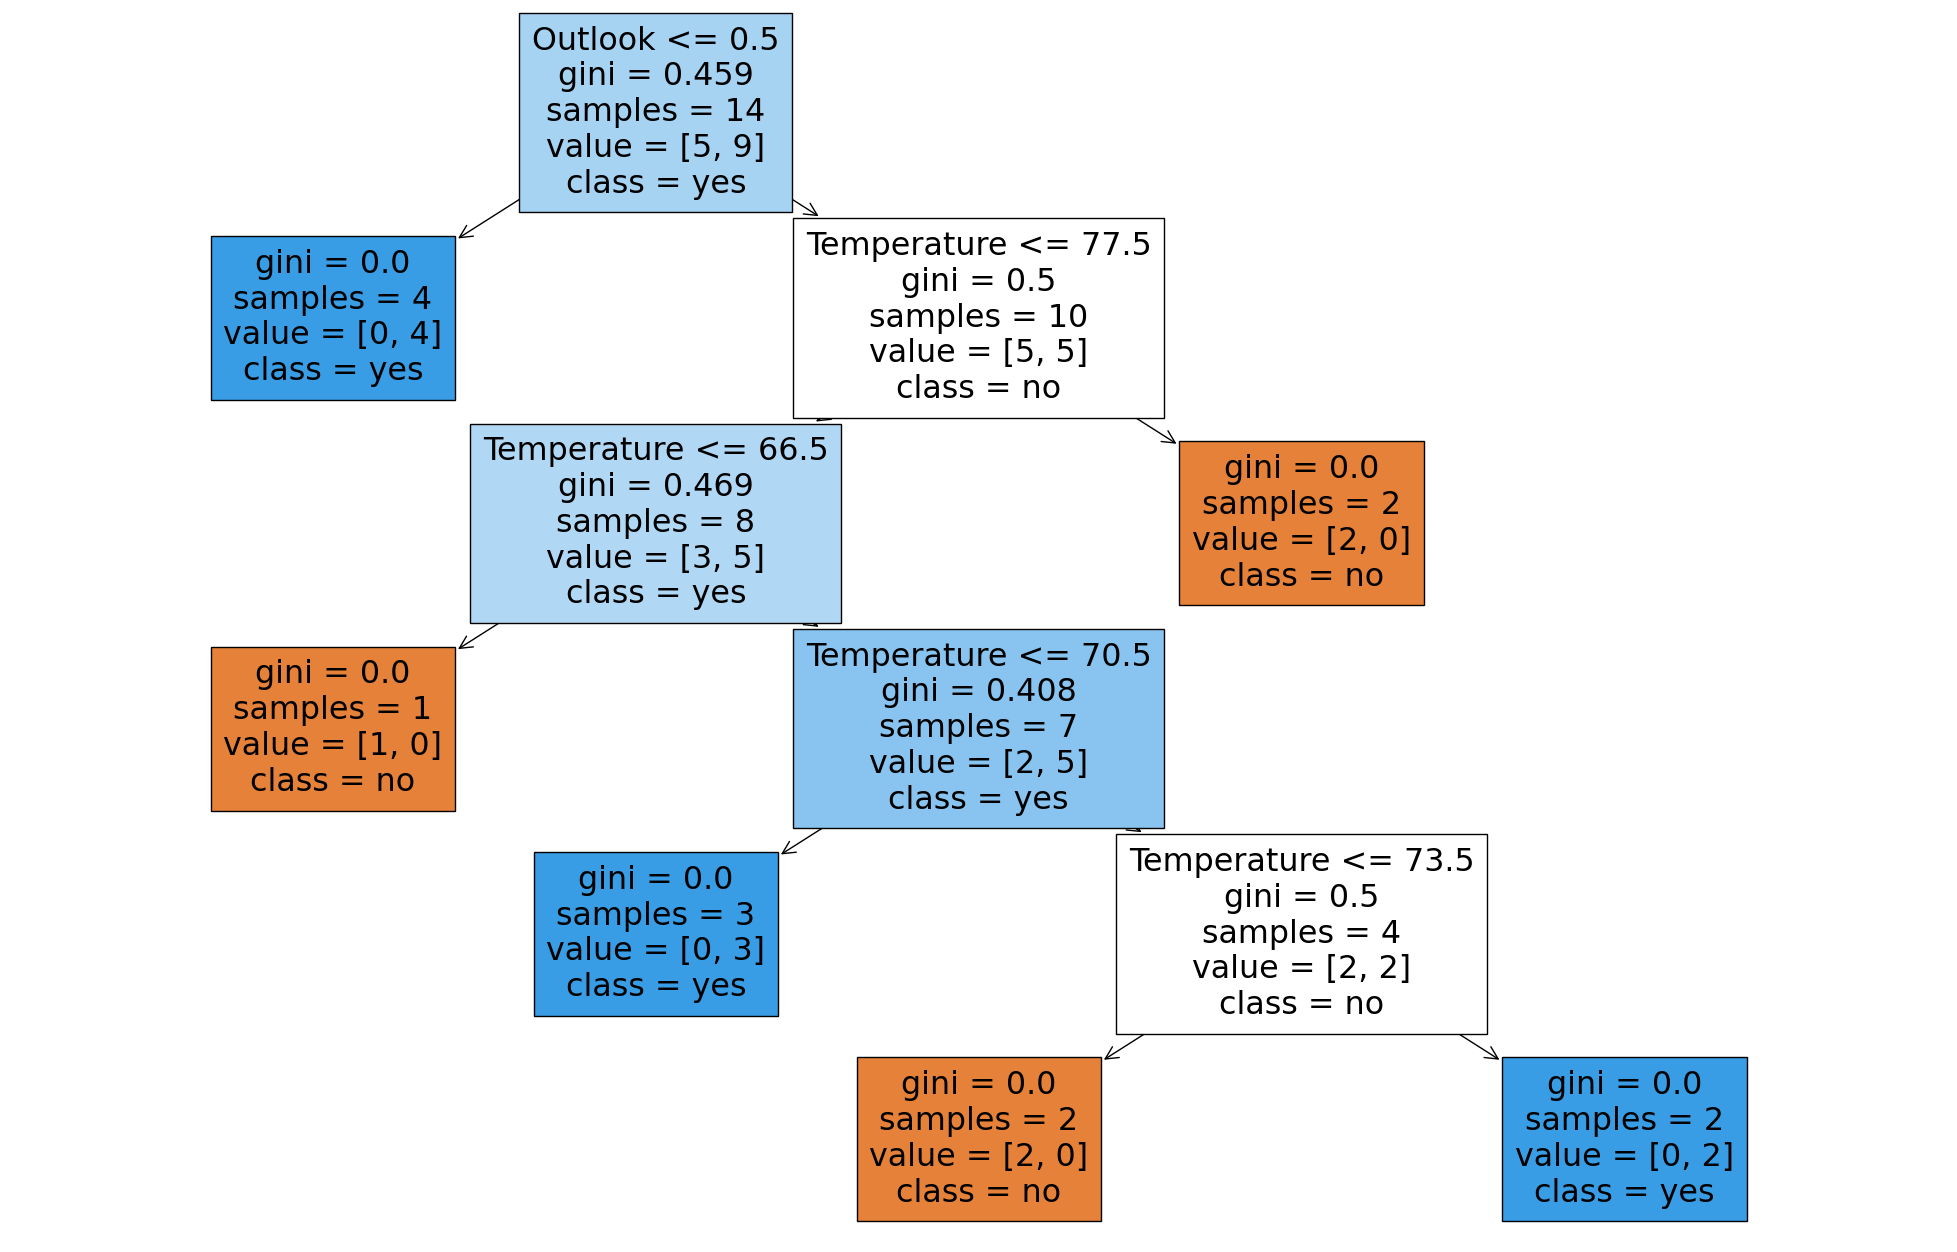

In [16]:
# can  also output the tree
dt_clf.fit(golf_X, golf_y)
plt.figure(figsize=(25, 16))
plot_tree(dt_clf, filled=True,
          feature_names=list(golf_X.columns),
          class_names=dt_clf.classes_)

In [17]:
# make a copy of the original golf data
golf2 = golf.copy()
# 2.1. aggregate temperature and humidity by taking the average between them
golf2['Temperature_Humidity'] = (golf2.Temperature + golf2.Humidity)/2
golf2.head()

,Outlook,Temperature,Humidity,Wind,Play,Temperature_Humidity
0,sunny,85,85,False,no,85.0
1,sunny,80,90,True,no,85.0
2,overcast,83,78,False,yes,80.5
3,rain,70,96,False,yes,83.0
4,rain,68,80,False,yes,74.0


In [18]:
# 2.2. aggregate outlook and wind by concatenating their values
# first, convert them to str, otherwise the concatenation will fail
golf2[['Outlook', 'Wind']] = golf2[['Outlook', 'Wind']].astype('str')
# add the new aggregated attribute
golf2['Outlook_Wind'] = golf2.Outlook + '_' + golf2.Wind
golf2.head()

,Outlook,Temperature,Humidity,Wind,Play,Temperature_Humidity,Outlook_Wind
0,sunny,85,85,False,no,85.0,sunny_False
1,sunny,80,90,True,no,85.0,sunny_True
2,overcast,83,78,False,yes,80.5,overcast_False
3,rain,70,96,False,yes,83.0,rain_False
4,rain,68,80,False,yes,74.0,rain_False


In [19]:
# 2.3. combine the values of rain and overcast in the outlook column
golf2['Outlook'].mask((golf2.Outlook == 'rain')|(golf2.Outlook == 'overcast'),
                      'rain_overcast', inplace=True)
golf2

,Outlook,Temperature,Humidity,Wind,Play,Temperature_Humidity,Outlook_Wind
0,sunny,85,85,False,no,85.0,sunny_False
1,sunny,80,90,True,no,85.0,sunny_True
2,rain_overcast,83,78,False,yes,80.5,overcast_False
3,rain_overcast,70,96,False,yes,83.0,rain_False
4,rain_overcast,68,80,False,yes,74.0,rain_False
5,rain_overcast,65,70,True,no,67.5,rain_True
6,rain_overcast,64,65,True,yes,64.5,overcast_True
7,sunny,72,95,False,no,83.5,sunny_False
8,sunny,69,70,False,yes,69.5,sunny_False
9,rain_overcast,75,80,False,yes,77.5,rain_False


In [20]:
# drop the original attributes, except outlook
golf2 = golf2.drop(['Temperature', 'Humidity', 'Wind'], axis=1)
# separate the reg.attr. from the label attr.
golf_X2 = golf2[golf2.columns.difference(['Play'])]
golf_y2 = golf2['Play']
## convert obj. cols to category cols
enc = OrdinalEncoder()
golf_X2[['Outlook', 'Outlook_Wind']] = enc.fit_transform(golf_X2[['Outlook', 'Outlook_Wind']])
# we will use a DT to model a baseline
dt_clf = DecisionTreeClassifier(random_state=43)
# only do crossval since we have a very small dataset
ad.cross_validation_avg_scores(golf_X2, golf_y2, dt_clf)

Mean Accuracy is 66.67 +/- 42.16
Mean Precision is 65.00 +/- 43.59
Mean Recall is 65.00 +/- 43.59
Mean F-score is 65.00 +/- 43.59


[Text(0.4, 0.875, 'Outlook_Wind <= 2.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]\nclass = yes'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]\nclass = yes'),
 Text(0.6, 0.625, 'Temperature_Humidity <= 74.0\ngini = 0.408\nsamples = 7\nvalue = [5, 2]\nclass = no'),
 Text(0.4, 0.375, 'Outlook_Wind <= 3.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = yes'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = no'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = yes'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = no')]

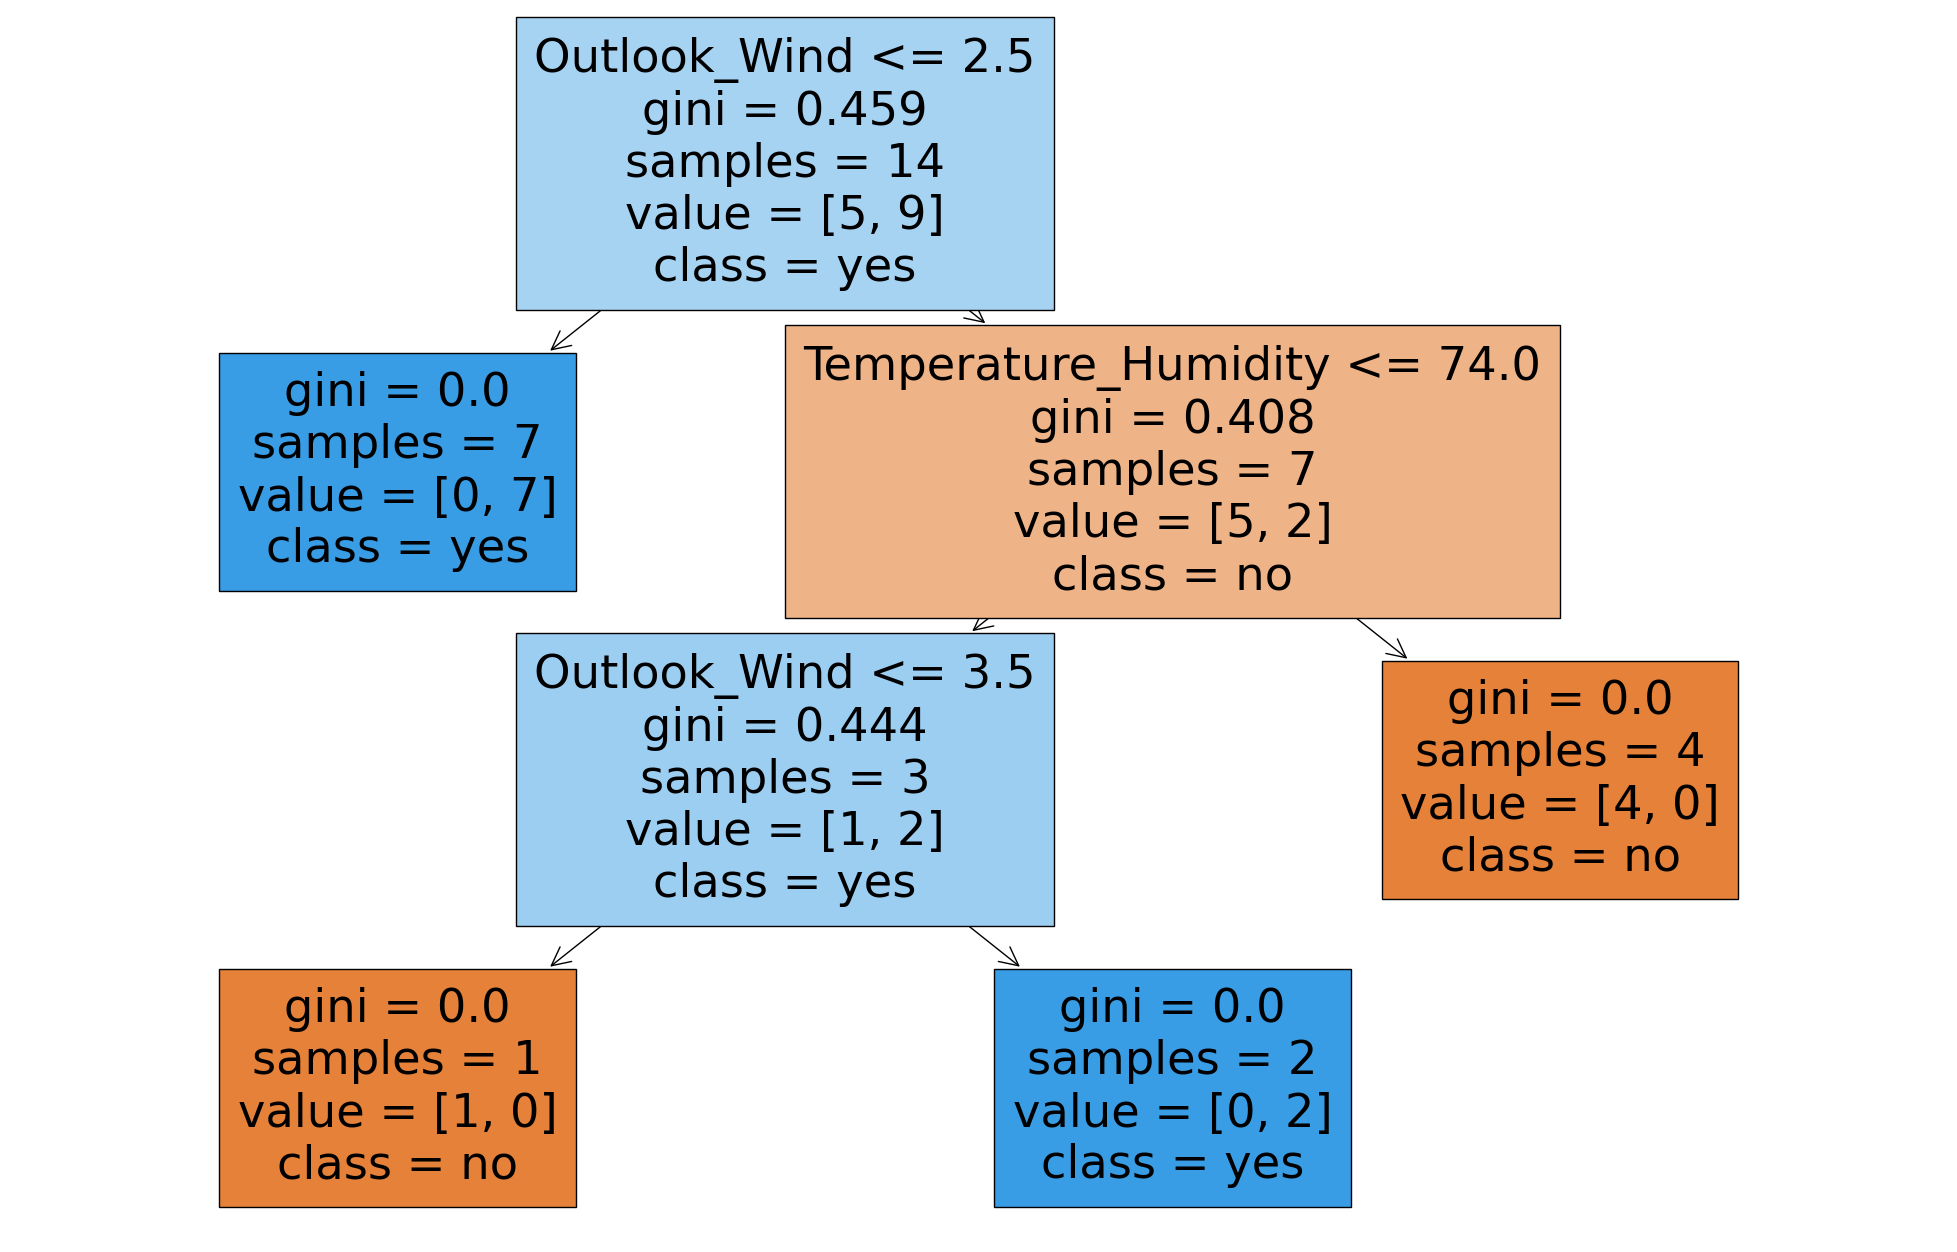

In [21]:
# can  also output the tree
dt_clf.fit(golf_X2, golf_y2)
plt.figure(figsize=(25, 16))
plot_tree(dt_clf, filled=True,
          feature_names=list(golf_X2.columns),
          class_names=dt_clf.classes_)

## SAMPLING
- we will work with the iris dataset

In [23]:
iris = pd.read_csv('data/iris.csv', sep=';')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   iris         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [24]:
# 1.1. sample randomly half the rows using the fraction argument
iris_rand_sample = iris.sample(frac=0.5, random_state=43, axis=0)
iris_rand_sample.iris.value_counts()

iris
Iris-versicolor    30
Iris-setosa        24
Iris-virginica     21
Name: count, dtype: int64

In [25]:
# 1.2. sample randomly half the rows using the exact number of rows
iris_rand_sample2 = iris.sample(n=75, random_state=43, axis=0)
iris_rand_sample2.iris.value_counts()

iris
Iris-versicolor    30
Iris-setosa        24
Iris-virginica     21
Name: count, dtype: int64

In [26]:
# 2. sample randomly half the rows from each of the 3 classes (stratified)
iris_rand_sample3 = iris.groupby('iris', group_keys=False).apply(
                      lambda x: x.sample(frac=0.5, random_state=43, axis=0))
iris_rand_sample3.iris.value_counts()

iris
Iris-setosa        25
Iris-versicolor    25
Iris-virginica     25
Name: count, dtype: int64

In [27]:
# 3. sampling appox. 2/3 of rows with kernard stone
# need to install the necessary library if not already on the system
!pip install kennard_stone
import kennard_stone
ks_X = iris.drop(['iris'], axis=1)
ks_y = iris['iris']
# can use the train_test_split which works the same as the scikit version
# so we can split based on the label column
ks_X_sample, _, ks_y_sample, _ = kennard_stone.train_test_split(
    ks_X, ks_y, test_size=0.3, random_state=43
    )
print(len(ks_X_sample), len(ks_y_sample))
# optionally we can put back together all attributes
ks_sample = pd.concat([ks_X_sample, ks_y_sample], axis=1)
ks_sample.iris.value_counts()

2025-04-21 18:38:31,413 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

2025-04-21 18:38:31,416 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.



105 105


iris
Iris-virginica     41
Iris-versicolor    37
Iris-setosa        27
Name: count, dtype: int64

In [28]:
# or we can split independent of the class label column in which case
# we need to convert the label attr because only works for numeric attributes
ks_iris = iris.copy()
enc = LabelEncoder()
ks_iris['iris'] = ks_iris[['iris']].apply(enc.fit_transform)
# keep 2/3
ks_iris_sample, _ = kennard_stone.train_test_split(ks_iris, test_size=0.3, random_state=43)
# reverse the encoding
ks_iris_sample.iris = ks_iris_sample[['iris']].apply(enc.inverse_transform)
ks_iris_sample.iris.value_counts()

2025-04-21 18:38:31,459 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

2025-04-21 18:38:31,462 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.



iris
Iris-virginica     40
Iris-versicolor    37
Iris-setosa        28
Name: count, dtype: int64

In [29]:
charity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2398 entries, 0 to 2397
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Pre-campaign expenditure      2398 non-null   float64
 1   Pre-campaign visits           2398 non-null   float64
 2   Pre-campaign spend category   2398 non-null   object 
 3   Pre-campaign visits category  2398 non-null   object 
 4   Total number of visits        2398 non-null   float64
 5   Total spend                   2398 non-null   float64
 6   Post Code                     2398 non-null   object 
 7   52 Mosaic Groups              2398 non-null   float64
 8   Mosaic Bands                  2398 non-null   float64
 9   Title                         2398 non-null   object 
 10  Gender                        2398 non-null   object 
 11  Year Of Birth                 2398 non-null   float64
 12  Age                           2398 non-null   float64
 13  Age

<Axes: >

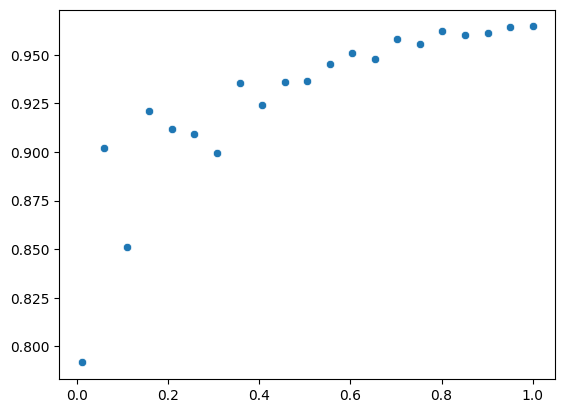

In [30]:
# 4. progressive sampling on the charity dataset using accuracy
# note: this can be optimised for recall or precision also, depending on the context
# use a loop to get accuracy scores for gradually bigger and bigger samples
# in each iteration add the accuracy score to a list
accuracies = []
dt_clf = DecisionTreeClassifier(random_state=43)
# create the range of fraction values between 0.01 and 1; limit these values to be 21 only
sizes = np.linspace(0.01, 1, num=21, endpoint=True)
for size in sizes:
  sample = charity.groupby('Response to campaign', group_keys=False).apply(
                      lambda x: x.sample(frac=size, random_state=43))
  X = sample[sample.columns.difference(['Response to campaign'])]
  y = sample['Response to campaign']
  obj_cols = X.select_dtypes(include=['object']).columns
  ord_enc = OrdinalEncoder()
  X[obj_cols] = ord_enc.fit_transform(X[obj_cols])
  preds = cross_val_predict(dt_clf, X, y)
  accuracies.append(accuracy_score(y, preds))
sns.scatterplot(x=sizes, y=accuracies)

In [ ]:
# EXERCISE: adapt the code to output recall, or precision or f1 scores and plot as abovwe; interpret the results

## CLASS IMBALANCE
- we will use the bmi dataset which is highly imbalanced; the class label column is Index which has 3 classes: underweight, normal, overweight
- we first get a baseline model and then look at 3 balancing options:
1. undersampling
2. oversampling
3. smote

In [31]:
bmi = pd.read_csv('data/bmi.csv')
bmi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    object
dtypes: int64(2), object(2)
memory usage: 15.8+ KB


In [32]:
bmi['Index'].value_counts()

Index
overweight     396
normal          69
underweight     35
Name: count, dtype: int64

In [33]:
# separate the reg.attr. from the label attr.
bmi_X = bmi[bmi.columns.difference(['Index'])]
bmi_y = bmi['Index']
# convert obj. cols to category cols
bmi_obj_cols = bmi_X.select_dtypes(include=['object']).columns
ord_enc = OrdinalEncoder()
bmi_X[bmi_obj_cols] = ord_enc.fit_transform(bmi_X[bmi_obj_cols])
X_train, X_test, y_train, y_test = train_test_split(bmi_X, bmi_y, test_size=0.3, random_state=43)
y_train.value_counts()

Index
overweight     276
normal          50
underweight     24
Name: count, dtype: int64

In [34]:
dt_clf = DecisionTreeClassifier(random_state=43)
# 0. get baseline model
ad.cross_validation_avg_scores(X_train, y_train, dt_clf)
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 92.00 +/- 3.21
Mean Precision is 85.35 +/- 6.44
Mean Recall is 81.24 +/- 7.73
Mean F-score is 81.75 +/- 7.36
              precision    recall  f1-score   support

      normal       0.79      0.58      0.67        19
  overweight       0.97      0.98      0.98       120
 underweight       0.71      0.91      0.80        11

    accuracy                           0.93       150
   macro avg       0.82      0.82      0.81       150
weighted avg       0.93      0.93      0.92       150



In [35]:
# 1. undersampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='auto', random_state=43)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(len(X_under), len(y_under))
print(y_under.value_counts())

72 72
Index
normal         24
overweight     24
underweight    24
Name: count, dtype: int64


In [36]:
# validate within each fold to ensure you account for instance leakage
prep = RandomUnderSampler(random_state=43)
ad.cross_val_pipeline(dt_clf, prep, X_train, y_train, imblearn_=True)
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 86.86 +/- 1.90
Mean Precision is 74.09 +/- 6.53
Mean Recall is 84.80 +/- 8.60
Mean F-score is 77.95 +/- 7.30
              precision    recall  f1-score   support

      normal       0.55      0.63      0.59        19
  overweight       0.98      0.92      0.95       120
 underweight       0.69      1.00      0.81        11

    accuracy                           0.89       150
   macro avg       0.74      0.85      0.78       150
weighted avg       0.91      0.89      0.89       150



In [37]:
# 2. oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=34)
X_over, y_over = ros.fit_resample(X_train, y_train)
print(len(X_over), len(y_over))
print(y_over.value_counts())

828 828
Index
overweight     276
underweight    276
normal         276
Name: count, dtype: int64


In [38]:
# validate within each fold to ensure you account for instance leakage
prep = RandomOverSampler(random_state=43)
ad.cross_val_pipeline(dt_clf, prep, X_train, y_train, imblearn_=True)
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 94.00 +/- 2.10
Mean Precision is 88.78 +/- 4.56
Mean Recall is 87.27 +/- 9.05
Mean F-score is 87.11 +/- 6.50
              precision    recall  f1-score   support

      normal       0.73      0.58      0.65        19
  overweight       0.97      0.97      0.97       120
 underweight       0.69      1.00      0.81        11

    accuracy                           0.92       150
   macro avg       0.80      0.85      0.81       150
weighted avg       0.92      0.92      0.92       150



In [39]:
# 3. SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=43, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(len(X_smote), len(y_smote))
print(y_smote.value_counts())

828 828
Index
overweight     276
underweight    276
normal         276
Name: count, dtype: int64


In [40]:
# validate within each fold to ensure you account for instance leakage
prep = SMOTE(random_state=43)
ad.cross_val_pipeline(dt_clf, prep, X_train, y_train, imblearn_=True)
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))
# EXERCISE: Experiment with different number of neigbours

Mean Accuracy is 94.57 +/- 1.40
Mean Precision is 86.54 +/- 5.45
Mean Recall is 86.85 +/- 7.69
Mean F-score is 85.88 +/- 6.56
              precision    recall  f1-score   support

      normal       0.74      0.74      0.74        19
  overweight       0.98      0.97      0.97       120
 underweight       0.77      0.91      0.83        11

    accuracy                           0.93       150
   macro avg       0.83      0.87      0.85       150
weighted avg       0.94      0.93      0.93       150



In [41]:
# 3.b. Borderline SMOTE
from imblearn.over_sampling import BorderlineSMOTE
blsmote = BorderlineSMOTE(random_state=43, k_neighbors=5, m_neighbors=10, kind='borderline-1')
X_blsmote, y_blsmote = blsmote.fit_resample(X_train, y_train)
print(len(X_blsmote), len(y_blsmote))
print(y_blsmote.value_counts())

828 828
Index
overweight     276
underweight    276
normal         276
Name: count, dtype: int64


In [42]:
# validate within each fold to ensure you account for instance leakage
prep = BorderlineSMOTE(random_state=43, k_neighbors=7, m_neighbors=16)
ad.cross_val_pipeline(dt_clf, prep, X_train, y_train, imblearn_=True)
y_pred = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred))
# EXERCISE: Experiment with different combinations of k_neighbors, m_neighbors, and kind
# EXERCISE: check out the imblearn documentation and try to understand the SMOTE variants
# and ADASYN hyperparameters, and attempt to experiment with different combinations.

Mean Accuracy is 95.71 +/- 1.81
Mean Precision is 91.88 +/- 2.85
Mean Recall is 91.06 +/- 4.47
Mean F-score is 90.41 +/- 3.68
              precision    recall  f1-score   support

      normal       0.79      0.79      0.79        19
  overweight       0.99      0.97      0.98       120
 underweight       0.79      1.00      0.88        11

    accuracy                           0.95       150
   macro avg       0.86      0.92      0.88       150
weighted avg       0.95      0.95      0.95       150



## VARIABLE TRANSFORMATIONS
### ENCODING AND TYPE CONVERSIONS
1. nominal/categorical to numerical (there are different ways to do this, including those we have used in the 1st semester to encode categorical variables: LabelEncoder for individual columns, OrdinalEncoder for multiple columns, and apply a map function)
2. nominal/categorical  to binominal
3. numeric to binominal
4. numeric to nominal

We will use the golf dataset

In [43]:
# 1. nominal to numerical using custom values using boolean masks
# (can be done using map as in 1st sem which is much simpler)
# make a copy first
golf3 = golf.copy()
golf3.Outlook[golf3.Outlook == 'sunny'] = 1
golf3.Outlook[golf3.Outlook == 'overcast'] = 2
golf3.Outlook[golf3.Outlook == 'rain'] = 3
# the outlook column is still an object, so it needs to be
# explicitly converted to integer
golf3.Outlook = golf3.Outlook.astype('int64')
golf3.head()

,Outlook,Temperature,Humidity,Wind,Play
0,1,85,85,False,no
1,1,80,90,True,no
2,2,83,78,False,yes
3,3,70,96,False,yes
4,3,68,80,False,yes


In [44]:
# 2. dummy encoding/one-hot-encoding using pandas
# note: sklearn also has the OneHotEncoder class to do this
# make a copy first
golf5 = golf.copy()
golf5 = pd.get_dummies(golf5, columns=['Outlook'])
golf5.head()

,Temperature,Humidity,Wind,Play,Outlook_overcast,Outlook_rain,Outlook_sunny
0,85,85,False,no,False,False,True
1,80,90,True,no,False,False,True
2,83,78,False,yes,True,False,False
3,70,96,False,yes,False,True,False
4,68,80,False,yes,False,True,False


In [45]:
# 3. numeric to binomial using a boolean mask or lambdas, e.g. True if <=85, False otherwise
# make a copy first
golf6 = golf.copy()
golf6['Humidity']= golf6['Humidity'].apply(lambda x: True if x <= 85 else False)
golf6.head()

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85,True,False,no
1,sunny,80,False,True,no
2,overcast,83,True,False,yes
3,rain,70,False,False,yes
4,rain,68,True,False,yes


In [46]:
# 4. numeric to polynomial, e.g., in temperature each value becomes a string
# make a copy first
golf7 = golf.copy()
golf7.Temperature = golf7.Temperature.apply(lambda x: str(x))
golf7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     int64 
 3   Wind         14 non-null     bool  
 4   Play         14 non-null     object
dtypes: bool(1), int64(1), object(3)
memory usage: 594.0+ bytes


### NORMALISATION/SCALING
- when working with certain algorithms such as KNN, you should standadise numerical attributes.
- we will look at 3 options:
1. min-max
2. standard scaling
3. interquartile scaling

In [48]:
iris = pd.read_csv('data/iris.csv', sep=';')
# separate regular attributes from the label column
X_iris = iris[iris.columns.difference(['iris'])]
y_iris = iris['iris']

array([[<Axes: title={'center': 'sepalwidth'}>,
        <Axes: title={'center': 'mm'}>],
       [<Axes: title={'center': 'std'}>, <Axes: title={'center': 'iqr'}>]],
      dtype=object)

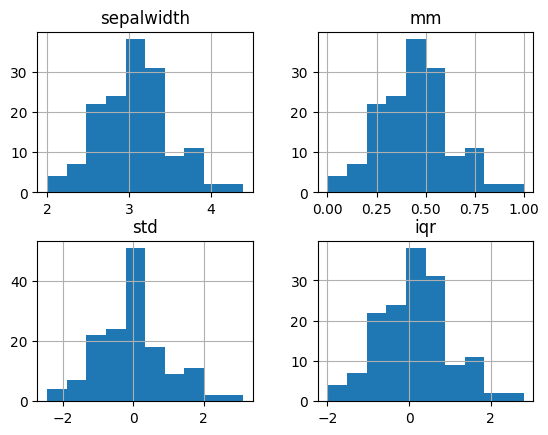

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
scaled = X_iris[['sepalwidth']].copy()
scaled[['mm']] = MinMaxScaler().fit_transform(scaled[['sepalwidth']])
scaled[['std']] = StandardScaler().fit_transform(scaled[['sepalwidth']])
scaled[['iqr']] = RobustScaler().fit_transform(scaled[['sepalwidth']])
scaled.hist()

In [50]:
# EXERCISE: use a dataset that has numeric columns and apply a classification algorithm that requires scaling to
# generate a baseline through crossvalidation on the training portion then apply last model to the test portion
# then use a similar approach, but this time, choose an appropriate scaling method to include in the pipeline;
# compare and discuss performances.

### TRANSFORMATIONS USING SIMPLE MATHEMATICAL FUNCTIONS
- typically, the original attributes should be discarded and replaced with the transformed versions; however, for now we are going to keep both versions for comaprison reasons
- exercise: derive new models with the transformed versions of attributes, then compare it against baseline and discuss.

In [51]:
poly = pd.read_csv('data/poly.csv')
poly.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/poly.csv'

In [ ]:
# 1. 1/x
poly['one/a1'] = 1/poly.a1
poly.head()

In [ ]:
# 2. exponential(x)
poly['exp(a1)'] = poly.a1.apply(np.exp)
poly.head()

In [ ]:
# 3. sqrt(x)
poly['sqrt(a1)'] = poly.a1.apply(np.sqrt)
poly.head()

In [ ]:
# 4. log2(x)
poly['log2(a1)'] = poly.a1.apply(np.log2)
poly.head()

### STRING TRANSFORMATIONS
- useful for solving inconsistencies, e.g. Ms and MS are the same word but different case
- useful when working with text data


In [ ]:
# capitalising all values in 'Outlook'
golf['Outlook'].apply(lambda x: x.upper())

In [ ]:
# getting the number of characters in each value
golf['Outlook'].apply(lambda x: len(x))

In [ ]:
golf['Outlook'].apply(lambda x: x.startswith('s'))

## ATTRIBUTE CONSTRUCTION
- Generating new attributes from existing ones.
- we will look at 2 ways:
  - using pandas library
  - using feature-engine library to create tree-based features (works for numeric features only)
    - Note: we can also use from here RelativeFeatures classes

In [ ]:
# 1. using pandas
# make a copy
golf8 = golf_X.copy()
# temperature is inversely proportional to humidity, so maybe we can add a new column that looks at the ratio between them
golf8['temp/hum'] = golf_X.Temperature / golf_X.Humidity
golf8.head()

In [ ]:
# 2. use feature engine library to create new features through DT supervised leaning
from feature_engine.creation import DecisionTreeFeatures
# create a copy
golf9= golf_X.copy()
# a. create all possible combinations of any 1 and 2 existing features
dtf = DecisionTreeFeatures(features_to_combine=2, regression=False, random_state=43)
# add the new features
golf9 = dtf.fit_transform(golf9, golf_y)
golf9.head()

In [ ]:
# create a copy
golf10= golf_X.copy()
# a. create all possible combinations of any 2 existing features
dtf = DecisionTreeFeatures(features_to_combine=[2], regression=False, random_state=43)
# add the new features
golf10 = dtf.fit_transform(golf10, golf_y)
golf10.head()

In [ ]:
# create a copy
golf11= golf_X.copy()
# create custom combinations of features
features = (('Outlook', 'Humidity'),
            ('Outlook', 'Humidity', 'Temperature'))
dtf = DecisionTreeFeatures(features_to_combine=features, regression=False, random_state=43)
# add the new features
golf11 = dtf.fit_transform(golf11, golf_y)
golf11.head()

**Exercises**:
- check out the documentation to see what other hyperparameters can be modified  and experiment with different combinations.
- derive new models after each new attribute created (note: unlike with transformations, we do not replace the original attributes) and compare and discuss performance.